# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [1]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<AxesSubplot:ylabel='Frequency'>

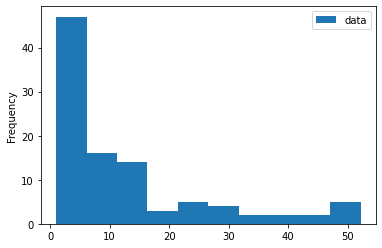

In [2]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

#### Histogram:

Pros:

- Shows the overall shape of the distribution, which is useful for identifying skewness and modality, revealing that most drug prices are on the lower end, with a long right tail indicating some very expensive drugs.
- Provides frequency counts, helping identify price ranges where most drugs fall.
- Can help visualize outliers, especially if the bins are appropriately chosen.

Cons:
- Does not directly indicate summary statistics (like quartiles, median, or outliers).
- The right-skewed nature of the data makes it harder to interpret the exact high-end drug prices.


<AxesSubplot:>

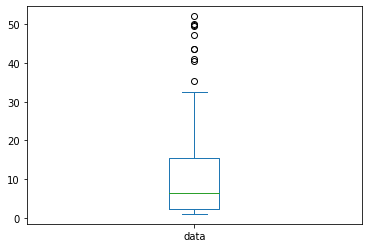

In [3]:
df.plot.box()

#### Boxplot

Pros:

- Clearly highlights outliers, which represent the most expensive drugs.
- Provides a compact summary of price distribution, including median, quartiles, and overall spread.
- Easier to compare price levels at a glance.

Cons:

- Doesn't show frequency or density within different price ranges.
- Lacks insight into the shape of the distribution (e.g., how prices are clustered).

#### I would recommend the boxplot. This is because:

- It explicitly shows outliers, which are crucial for understanding the higher-end drug prices.
- It provides a clear percentile breakdown, especially the 75th percentile.

#### Formatting Improvements:

Histogram:

- I would use logarithmic bins since the data is exponential, making the distribution more interpretable.
- Adjust bin size to ensure a smooth and informative visualization.
- Label axes clearly, e.g., “Price (log scale)” vs. “Frequency.”

Boxplot:
- Add annotations for key percentiles to improve readability.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [5]:
# 1st dataset
file_path_realtor =  "/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/cleaned datasets/week 2/updated_real_estate.csv" 
real_estate_df = pd.read_csv(file_path_realtor)
print(real_estate_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2223239 entries, 0 to 2223238
Data columns (total 11 columns):
 #   Column             Dtype  
---  ------             -----  
 0   status             object 
 1   price              float64
 2   bed                float64
 3   bath               float64
 4   acre_lot           float64
 5   city               object 
 6   state              object 
 7   zip_code           float64
 8   house_size         float64
 9   prev_sold_date     object 
 10  prev_sold_encoded  int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 186.6+ MB
None


In [6]:
real_estate_df.head()


,status,price,bed,bath,acre_lot,city,state,zip_code,house_size,prev_sold_date,prev_sold_encoded
0,for_sale,105000.0,3.0,2.0,0.12,Adjuntas,Puerto Rico,601.0,920.0,No,0
1,for_sale,80000.0,4.0,2.0,0.08,Adjuntas,Puerto Rico,601.0,1527.0,No,0
2,for_sale,67000.0,2.0,1.0,0.15,Juana Diaz,Puerto Rico,795.0,748.0,No,0
3,for_sale,145000.0,4.0,2.0,0.10,Ponce,Puerto Rico,731.0,1800.0,No,0
4,for_sale,65000.0,6.0,2.0,0.05,Mayaguez,Puerto Rico,680.0,1200.0,No,0


The data spans a very wide range, so I am using log scale. 

In [7]:
# Apply log scale transformation for price and house_size
real_estate_df['log_price'] = np.log(real_estate_df['price'] + 1)  # Adding 1 to avoid log(0)
real_estate_df['log_house_size'] = np.log(real_estate_df['house_size'] + 1)

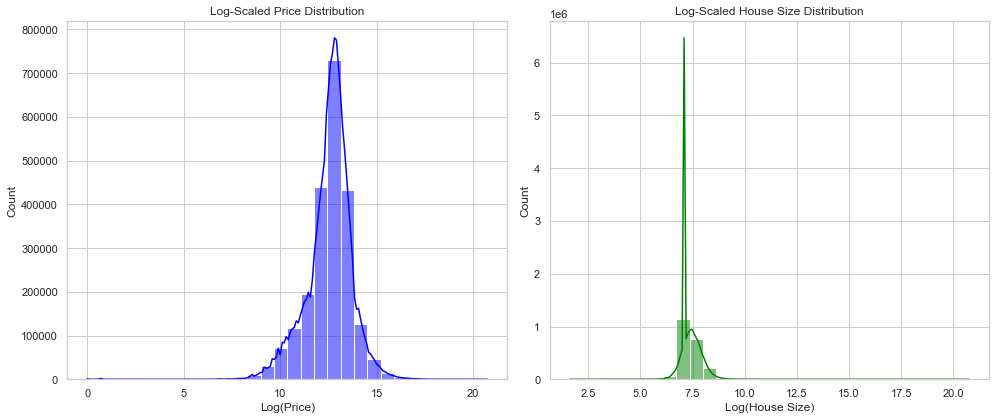

In [8]:

# Set seaborn style
sns.set(style="whitegrid")

# 1. Histograms with log scale
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot histogram for log-transformed price
sns.histplot(real_estate_df['log_price'], bins=30, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Log-Scaled Price Distribution')
axes[0].set_xlabel('Log(Price)')

# Plot histogram for log-transformed house_size
sns.histplot(real_estate_df['log_house_size'], bins=30, kde=True, color='green', ax=axes[1])
axes[1].set_title('Log-Scaled House Size Distribution')
axes[1].set_xlabel('Log(House Size)')

plt.tight_layout()
plt.show()

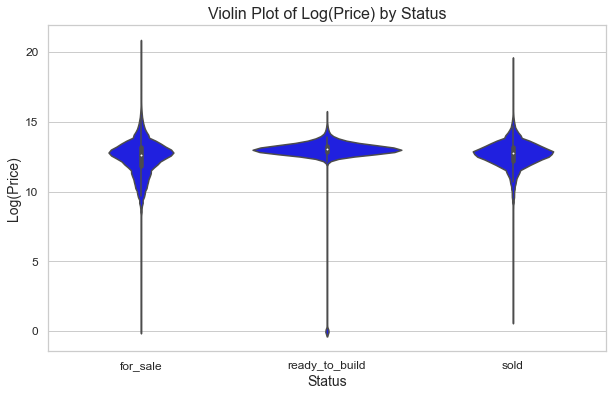

In [34]:
# 3. Violin plot for price and house_size by status
plt.figure(figsize=(10, 6))
sns.violinplot(x='status', y='log_price', data=real_estate_df, color='blue')

plt.title('Violin Plot of Log(Price) by Status', fontsize=16)
plt.xlabel('Status', fontsize=14)
plt.ylabel('Log(Price)', fontsize=14)

plt.xticks(fontsize=12)  # Adjusts tick labels on x-axis
plt.yticks(fontsize=12)  # Adjusts tick labels on y-axis

plt.show()


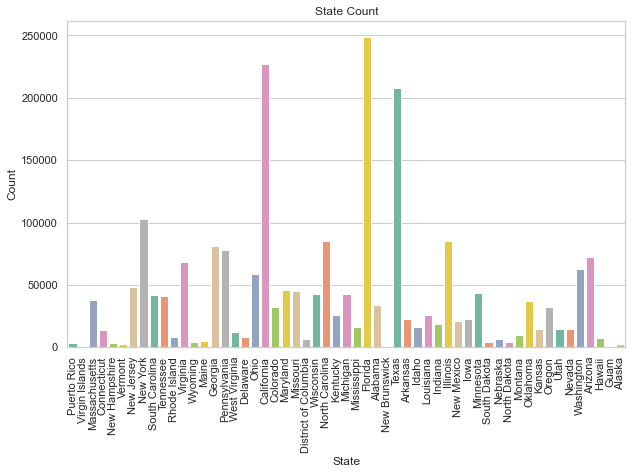

In [32]:
 # Bar plot for state
plt.figure(figsize=(10, 6))
sns.countplot(x='state', data=real_estate_df, palette='Set2')
plt.title('State Count')
plt.xlabel('State')
plt.ylabel('Count')
plt.xticks(rotation=90)  # Rotate x-axis labels if they are long
plt.show()

It shows how many rows aka houses are from each state.

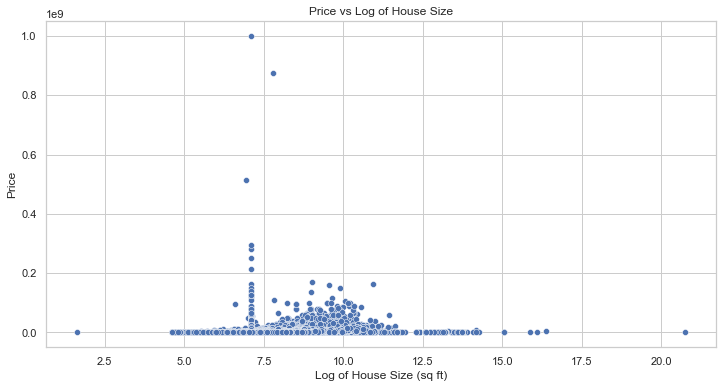

In [11]:
real_estate_df['log_house_size'] = np.log1p(real_estate_df['house_size'])

# Plot using the log-transformed house size
plt.figure(figsize=(12, 6))
sns.scatterplot(data=real_estate_df, x='log_house_size', y='price')
plt.title('Price vs Log of House Size')
plt.xlabel('Log of House Size (sq ft)')
plt.ylabel('Price')
plt.show()


In [12]:
summary_stats = {
    'Mean Price': real_estate_df['log_price'].mean(),
    'Median Price': real_estate_df['log_price'].median(),
    'Mode Price': real_estate_df['log_price'].mode()[0],
    'Mean House Size': real_estate_df['log_house_size'].mean(),
    'Median House Size': real_estate_df['log_house_size'].median(),
    'Mode House Size': real_estate_df['log_house_size'].mode()[0]
}

print("Summary Statistics:")
for stat, value in summary_stats.items():
    print(f"{stat}: {value}")

Summary Statistics:
Mean Price: 12.546370872013783
Median Price: 12.691583538230217
Mode Price: 12.765691290604371
Mean House Size: 7.3891920024506
Median House Size: 7.275172319452771
Mode House Size: 7.0909098220799835


In [13]:
# 2nd dataset
file_path = "/Users/sohanaziz/Documents/AI for leaders sem 2/Datasets/austinHousingData.csv" 
df = pd.read_csv(file_path)

print(df.info())   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15171 entries, 0 to 15170
Data columns (total 47 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   zpid                        15171 non-null  int64  
 1   city                        15171 non-null  object 
 2   streetAddress               15171 non-null  object 
 3   zipcode                     15171 non-null  int64  
 4   description                 15171 non-null  object 
 5   latitude                    15171 non-null  float64
 6   longitude                   15171 non-null  float64
 7   propertyTaxRate             15171 non-null  float64
 8   garageSpaces                15171 non-null  int64  
 9   hasAssociation              15171 non-null  bool   
 10  hasCooling                  15171 non-null  bool   
 11  hasGarage                   15171 non-null  bool   
 12  hasHeating                  15171 non-null  bool   
 13  hasSpa                      151

In [14]:
print(df.head())

         zpid          city          streetAddress  zipcode  \
0   111373431  pflugerville   14424 Lake Victor Dr    78660   
1   120900430  pflugerville     1104 Strickling Dr    78660   
2  2084491383  pflugerville    1408 Fort Dessau Rd    78660   
3   120901374  pflugerville     1025 Strickling Dr    78660   
4    60134862  pflugerville  15005 Donna Jane Loop    78660   

                                         description   latitude  longitude  \
0  14424 Lake Victor Dr, Pflugerville, TX 78660 i...  30.430632 -97.663078   
1  Absolutely GORGEOUS 4 Bedroom home with 2 full...  30.432673 -97.661697   
2  Under construction - estimated completion in A...  30.409748 -97.639771   
3  Absolutely darling one story home in charming ...  30.432112 -97.661659   
4  Brimming with appeal & warm livability! Sleek ...  30.437368 -97.656860   

   propertyTaxRate  garageSpaces  hasAssociation  ...  numOfMiddleSchools  \
0             1.98             2            True  ...                   1  

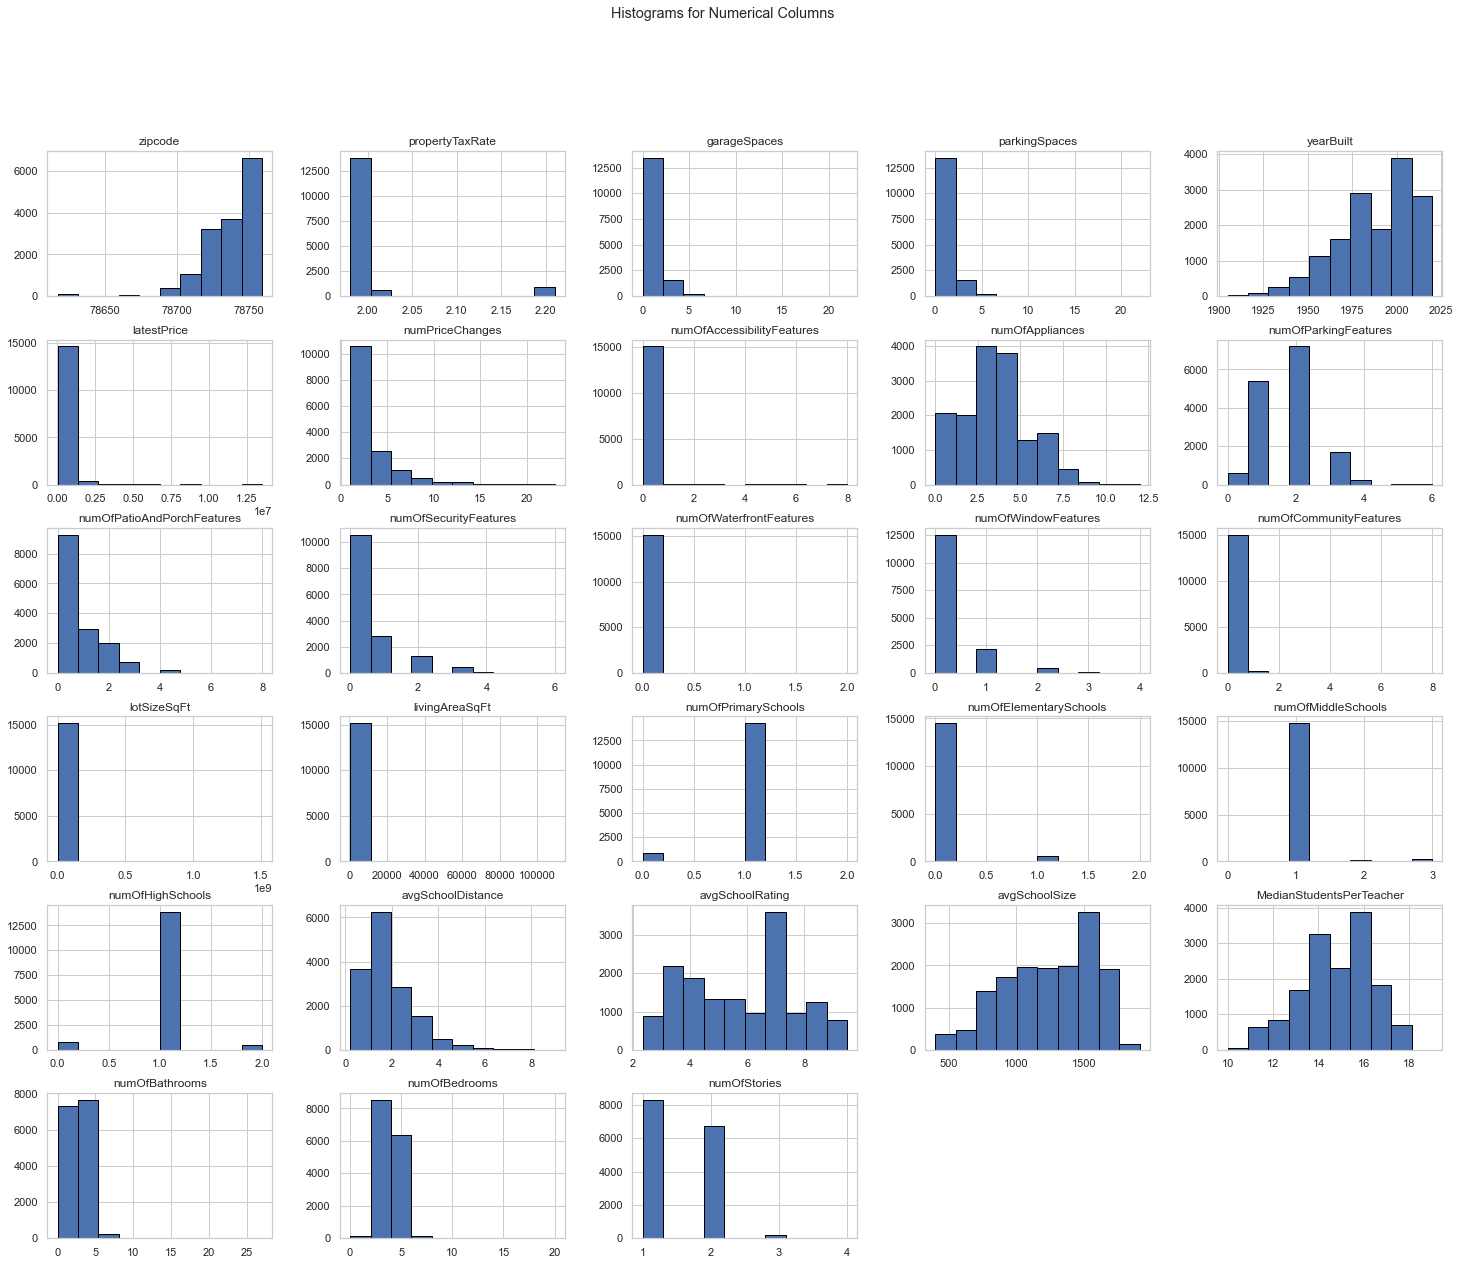

In [15]:
#Dropping some redundent columns
columns_to_drop = [
    "zpid", "streetAddress", "homeImage", "latestPriceSource",
    "latitude", "longitude", "hasGarage", 
    "latest_salemonth", "latest_saleyear", "description", "numOfPhotos"
]
df_cleaned = df.drop(columns=columns_to_drop)

# Histograms for the numerical columns
df_cleaned.hist(figsize=(25, 20), bins=10, edgecolor='black')
plt.suptitle("Histograms for Numerical Columns")
plt.show()

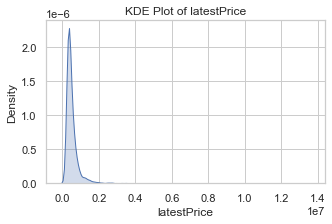

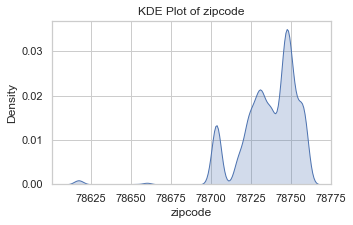

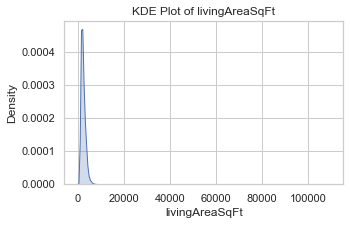

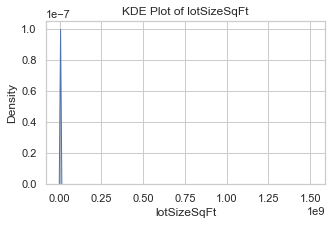

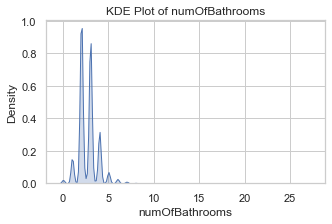

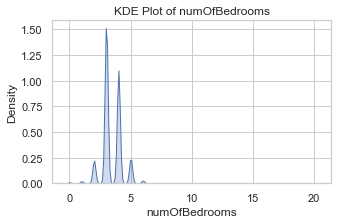

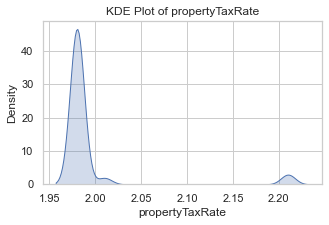

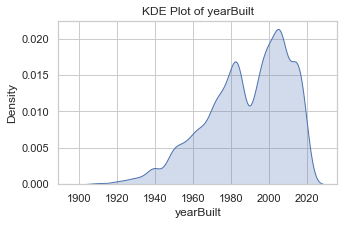

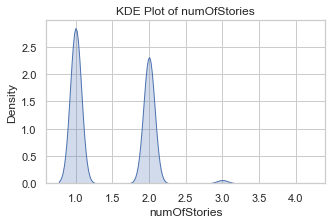

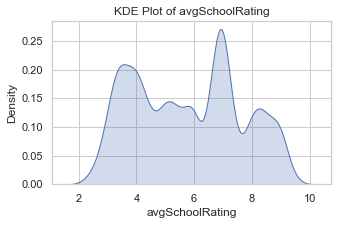

In [16]:
# KDE Plots for some numerical columns

numerical_columns = ["latestPrice","zipcode", "livingAreaSqFt", "lotSizeSqFt", "numOfBathrooms", 
                     "numOfBedrooms", "propertyTaxRate", "yearBuilt", "numOfStories", "avgSchoolRating"]

for col in numerical_columns:
    plt.figure(figsize=(5, 3))
    sns.kdeplot(df[col], fill=True)
    plt.title(f"KDE Plot of {col}")
    plt.show()


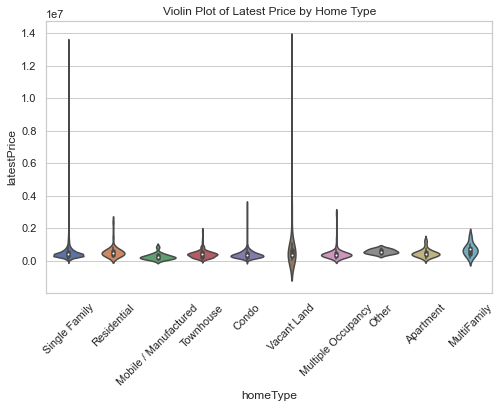

In [17]:
# Violin Plot for Latest Price by Home Type
plt.figure(figsize=(8, 5))
sns.violinplot(x=df_cleaned["homeType"], y=df_cleaned["latestPrice"])
plt.xticks(rotation=45)
plt.title("Violin Plot of Latest Price by Home Type")
plt.show()

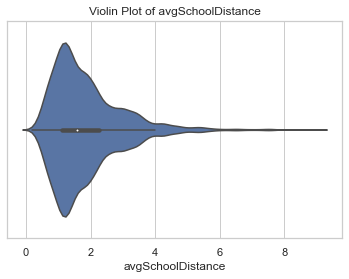

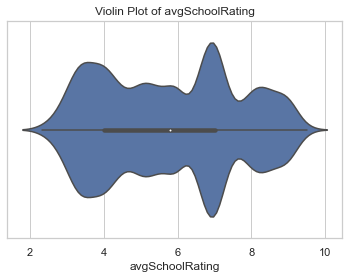

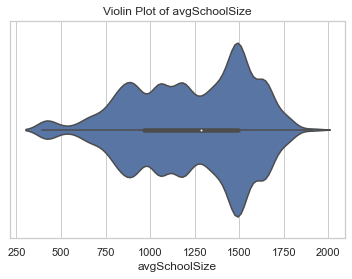

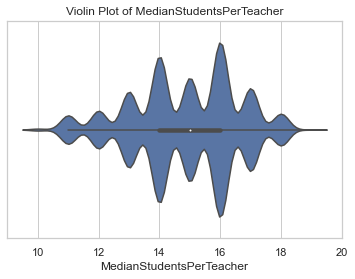

In [18]:
#violin plot for school features
school_features = ["avgSchoolDistance", "avgSchoolRating", "avgSchoolSize", "MedianStudentsPerTeacher"]

for col in school_features:
    plt.figure()
    sns.violinplot(x=df_cleaned[col])
    plt.title(f"Violin Plot of {col}")
    plt.show()

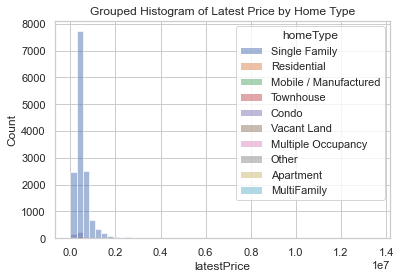

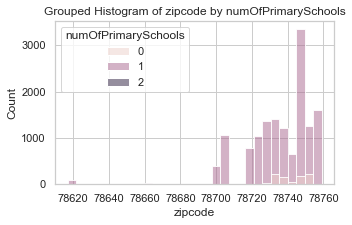

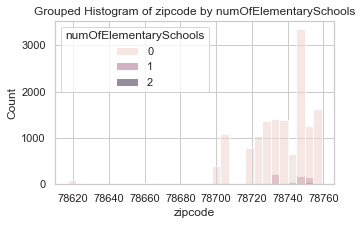

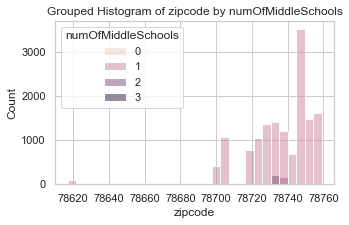

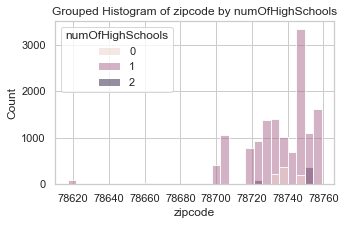

In [25]:
# Grouped Histogramsof Latest Price by Home Type
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="latestPrice", hue="homeType", bins=50, fill=True)
plt.title("Grouped Histogram of Latest Price by Home Type")
plt.show()

# Grouped Histograms for School Features
school_columns = ["numOfPrimarySchools", "numOfElementarySchools", "numOfMiddleSchools", "numOfHighSchools"]

for col in school_columns:
    plt.figure(figsize=(5, 3))
    sns.histplot(data=df, x="zipcode", hue=col, bins=30, fill=True)
    plt.title(f"Grouped Histogram of zipcode by {col}")
    plt.show()

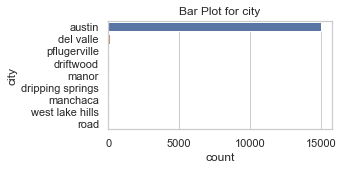

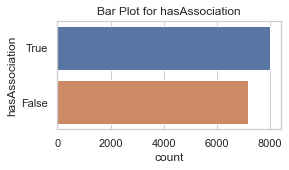

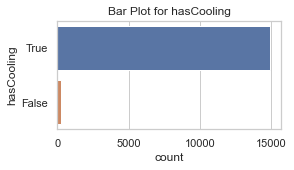

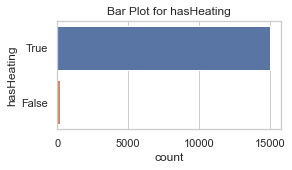

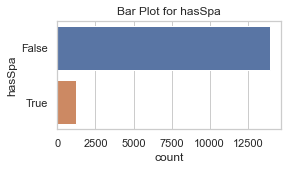

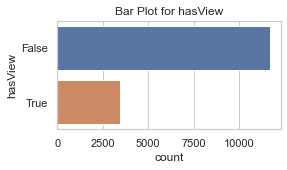

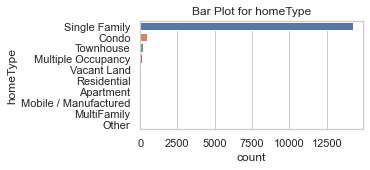

In [20]:
# Bar Plots for categorical columns
categorical_columns = df_cleaned.select_dtypes(include=['object', 'bool']).columns
categorical_columns = categorical_columns[categorical_columns != "latest_saledate"]  # Excluding 'latest_saledate' 

for col in categorical_columns:
    plt.figure(figsize=(4, 2))
    sns.countplot(y=df_cleaned[col], order=df_cleaned[col].value_counts().index)
    plt.title(f"Bar Plot for {col}")
    plt.show()

In [21]:
mean_median_column = ['propertyTaxRate', 'garageSpaces', 'latestPrice', 'numPriceChanges', 
                      'lotSizeSqFt', 'livingAreaSqFt', 'avgSchoolDistance', 'avgSchoolRating', 
                      'numOfBathrooms', 'numOfBedrooms', 'numOfStories', 'MedianStudentsPerTeacher']

# Calculate mean values for the selected columns in the DataFrame
mean_values = df[mean_median_column].mean()

print("Mean values:\n", mean_values)

Mean values:
 propertyTaxRate                  1.994085
garageSpaces                     1.229187
latestPrice                 512767.743722
numPriceChanges                  3.032892
lotSizeSqFt                 119083.968123
livingAreaSqFt                2208.323314
avgSchoolDistance                1.838495
avgSchoolRating                  5.779912
numOfBathrooms                   2.683010
numOfBedrooms                    3.440380
numOfStories                     1.467273
MedianStudentsPerTeacher        14.857228
dtype: float64


In [22]:
#Median 
median_values = df[mean_median_column].median()

print("Median values:\n", median_values)


Median values:
 propertyTaxRate                  1.980000
garageSpaces                     1.000000
latestPrice                 405000.000000
numPriceChanges                  2.000000
lotSizeSqFt                   8276.000000
livingAreaSqFt                1975.000000
avgSchoolDistance                1.566667
avgSchoolRating                  5.778694
numOfBathrooms                   3.000000
numOfBedrooms                    3.000000
numOfStories                     1.000000
MedianStudentsPerTeacher        15.000000
dtype: float64


In [23]:
# Mode
mode_values = df[['city', 'homeType', 'hasAssociation', 'hasCooling', 'hasHeating', 'hasSpa', 'hasView', 'zipcode', 'latest_saledate']].mode().iloc[0]
print("\nMode values:\n", mode_values)


Mode values:
 city                      austin
homeType           Single Family
hasAssociation              True
hasCooling                  True
hasHeating                  True
hasSpa                     False
hasView                    False
zipcode                    78748
latest_saledate       2019-06-28
Name: 0, dtype: object


#### Data Usability & Expectations
The dataset includes a mix of numerical and categorical features relevant to property valuation. The distributions of key numerical variables—such as latestPrice, livingAreaSqFt, and lotSizeSqFt—appear reasonable, indicating that the data is likely usable. The histograms suggest that certain zip codes and construction years are more frequent, which aligns with expected trends. More recent homes tend to have higher counts, and similar patterns are observed across other features.

#### Overall Shape of the Distributions
The KDE plot for property tax shows a sharp peak around 1.98–2, indicating that most properties fall within this tax range. The yearBuilt distribution highlights a significant increase in construction activity after the 1950s, with peaks in the 1980s and early 2000s.

Violin plots reveal that the average school size falls between 1,000 and 1,500 students, with fewer very small or very large schools. Additionally, most properties are located near schools, though school ratings are not evenly distributed.

The bar plots indicate that while heating and cooling systems are common in most homes, features like a scenic view or spa are relatively rare. The distributions of livingAreaSqFt and lotSizeSqFt are right-skewed, as larger homes and lots are less frequent. Property tax rates, however, appear more uniformly distributed across different areas. 

The number of bedrooms and bathrooms peaks around common values (e.g., 2–4 bedrooms).

#### Outliers
Violin plots for price distribution across key categorical features clearly highlight outliers. Some properties—especially vacant land and luxury single-family homes—are significantly more expensive than the rest, which could skew analyses.

#### Distribution Changes Across Groups
School-related features, such as avgSchoolRating and numOfSchools, suggest that homes near highly rated schools tend to be more expensive. Additionally, property prices vary notably across different neighborhoods. Grouped histograms reveal that certain zip codes have a higher number of schools, which may indicate more affluent areas.

Despite the presence of outliers, the mean and median values do not appear excessively large or small, suggesting that these outliers are unlikely to severely distort the overall analysis.

#### Effect of Bin Size on Histograms
The choice of bin size in histograms affects interpretability. Larger bin sizes may oversimplify the data, masking important variations, while smaller bin sizes can introduce excessive noise, making patterns harder to discern.

Since the mean and median values are close, the overall distributions do not appear heavily skewed. KDE plots for variables like numOfBathrooms, numOfBedrooms, yearBuilt, and avgSchoolRating display multiple peaks, indicating bimodal distributions.

To improve model efficiency, some uninformative features have been dropped, ensuring that only the most relevant variables contribute to analysis and predictions.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

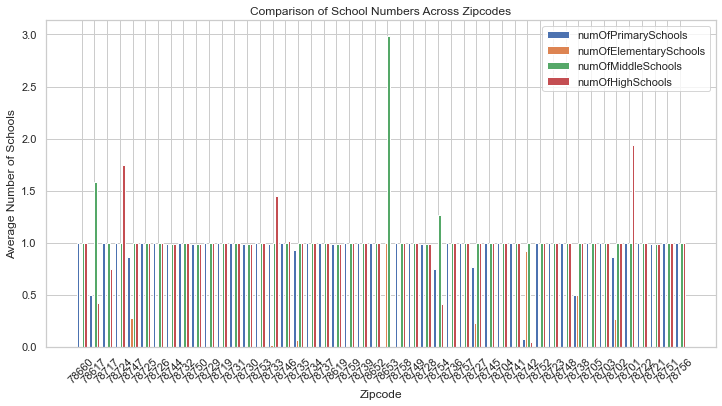

In [24]:
# Multiple series bar chart of school-related categories grouped by zipcode from Storytelling With Data book 

categories = ["numOfPrimarySchools", "numOfElementarySchools", "numOfMiddleSchools", "numOfHighSchools"]
zipcodes = df["zipcode"].unique()

x = np.arange(len(zipcodes))  # Label locations
width = 0.2  # Bar width

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars for each school type
for i, category in enumerate(categories):
    ax.bar(x + i * width, df.groupby("zipcode")[category].mean(), width, label=category)

ax.set_xlabel("Zipcode")
ax.set_ylabel("Average Number of Schools")
ax.set_title("Comparison of School Numbers Across Zipcodes")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(zipcodes, rotation=45)
ax.legend()

plt.show()